# 07 — Models v2: every row, NaN-native boosting, honest tuning, calibrated probabilities

**Question this notebook answers:** with the leakage understood (notebook 03), how well can a properly built model predict a KOI's archive disposition from physics alone, and can we trust its probabilities?

**Inputs:** the cleaned table (notebook 01), *all 9,564 rows*. **Outputs:** `reports/tables/07_models_v2_metrics.csv`, figures in `reports/figures/models/`, and the physics-only model saved to `models/` (ignored by git; the app phase decides how it ships).

> **What is new versus notebook 03**
> - **No rows are dropped.** `HistGradientBoostingClassifier` routes missing values natively, and `<column>_missing` indicators let the model use the fact that a value is missing (the review showed missingness tracks the label).
> - **Hyperparameters are chosen on validation folds, never on the test fold** (nested cross-validation: 5 outer × 3 inner).
> - **Probabilities are checked**, not just labels: reliability diagrams, log loss and Brier score, before and after calibration.
> - **Feature importance without leakage**: permutation importance on the physics-only model.
> - Two feature sets, as always: `physics_only` (the honest problem) and `with_flags` (the vetting-logic reproduction).

*(Numbering note: there is no notebook 06. House rule.)*

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import dump
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score

from kepler import data, preprocess, viz
from kepler.data import CLASSES, TARGET, label
from kepler.models import (
    HGB_GRID, add_missing_indicators, brier_multiclass, hgb_model, nested_cv, reliability_table, score, split,
)
from kepler.paths import FIGURES, MODELS, REPORTS

warnings.filterwarnings("ignore")
viz.apply_style()
FIG_DIR = FIGURES / "models"; FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = REPORTS / "tables"; TABLE_DIR.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 160); pd.set_option("display.precision", 3)

## 1. Data: all 9,564 KOIs, missing values kept

Each feature set is the notebook-03 set plus a `_missing` indicator for every column that has any NaN. Target codes: 0 CANDIDATE, 1 CONFIRMED, 2 FALSE POSITIVE.

In [2]:
clean = preprocess.clean(data.load_kaggle_snapshot())
tables = {}
for name in ("physics_only", "with_flags"):
    t = preprocess.model_table(clean, name, dropna=False)
    tables[name] = (add_missing_indicators(t.X), t.y)
    X, y = tables[name]
    print(f"{name:13s} rows {len(X):,} | columns {X.shape[1]} (indicators: {sum(c.endswith('_missing') for c in X.columns)}) | classes {y.value_counts().sort_index().tolist()}")

physics_only  rows 9,564 | columns 22 (indicators: 10) | classes [2248, 2293, 5023]
with_flags    rows 9,564 | columns 26 (indicators: 10) | classes [2248, 2293, 5023]


## 2. Nested cross-validation

For each of 5 outer folds, a grid search over learning rate, tree size and leaf size runs on 3 inner folds of the *training* part; the chosen model is then scored once on the outer test fold. Every number below is an outer-fold number. (This cell takes a few minutes.)

In [3]:
results = {}
for name, (X, y) in tables.items():
    results[name] = nested_cv(hgb_model(), HGB_GRID, X, y, outer_splits=5, inner_splits=3, random_state=0)
    print(f"{name}: chosen params per fold -> {results[name].params}")
summary = pd.DataFrame({name: r.summary for name, r in results.items()})
summary

physics_only: chosen params per fold -> [{'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}, {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'min_samples_leaf': 20}, {'learning_rate': 0.1, 'max_leaf_nodes': 31, 'min_samples_leaf': 50}, {'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}, {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'min_samples_leaf': 20}]


with_flags: chosen params per fold -> [{'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}, {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}, {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}, {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}, {'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}]


,physics_only,with_flags
f1_macro,0.722 ± 0.006,0.862 ± 0.007
balanced_accuracy,0.733 ± 0.006,0.863 ± 0.007
accuracy,0.754 ± 0.006,0.896 ± 0.004
f1_CANDIDATE,0.552 ± 0.014,0.786 ± 0.013
f1_CONFIRMED,0.780 ± 0.015,0.819 ± 0.009
f1_FALSE POSITIVE,0.835 ± 0.008,0.982 ± 0.003
log_loss,0.578 ± 0.006,0.258 ± 0.003


### Was it the extra rows, or the model?

Same boosting model, fixed at the most-chosen parameters, on the **complete rows only** (what a `dropna` pipeline sees), so the gain from keeping incomplete rows can be separated from the gain from the model class and tuning. Notebook 03's dropna gradient boosting is the reference point.

In [4]:
from collections import Counter
ref = pd.read_csv(TABLE_DIR / "03_baseline_metrics.csv")
ref_cv = ref[(ref["evaluation"] == "5-fold CV") & (ref["model"] == "gradient_boosting")].set_index("feature_set")
rows = []
for name, (X, y) in tables.items():
    best = Counter(tuple(sorted(p.items())) for p in results[name].params).most_common(1)[0][0]
    best = dict(best)
    complete = ~X[[c for c in X.columns if not c.endswith("_missing")]].isna().any(axis=1)
    Xc = X.loc[complete, [c for c in X.columns if not c.endswith("_missing")]]; yc = y[complete]
    folds = StratifiedKFold(5, shuffle=True, random_state=0)
    cv_complete = cross_val_score(hgb_model(**best), Xc, yc, cv=folds, scoring="f1_macro")
    rows.append({"feature_set": name,
                 "notebook 03: GBT (2020 settings), dropna rows": f"{ref_cv.loc[name, 'f1_macro_mean']:.3f} ± {ref_cv.loc[name, 'f1_macro_std']:.3f}",
                 "HGB tuned, complete rows only": f"{cv_complete.mean():.3f} ± {cv_complete.std():.3f}  (n={len(Xc):,})",
                 "HGB tuned, all rows + indicators (nested CV)": f"{results[name].folds['f1_macro'].mean():.3f} ± {results[name].folds['f1_macro'].std():.3f}  (n={len(X):,})",
                 "most-chosen params": best})
pd.DataFrame(rows).set_index("feature_set").T

feature_set,physics_only,with_flags
"notebook 03: GBT (2020 settings), dropna rows",0.715 ± 0.015,0.861 ± 0.007
"HGB tuned, complete rows only","0.723 ± 0.011 (n=9,200)","0.861 ± 0.010 (n=9,200)"
"HGB tuned, all rows + indicators (nested CV)","0.722 ± 0.006 (n=9,564)","0.862 ± 0.007 (n=9,564)"
most-chosen params,"{'learning_rate': 0.05, 'max_leaf_nodes': 31, ...","{'learning_rate': 0.05, 'max_leaf_nodes': 15, ..."


> **Reading the table.** On physics alone the ceiling barely moves: about **0.72 macro f1** whichever way it is built. Keeping every row and tuning honestly buys a couple of thousandths, not a breakthrough. The information that separates CANDIDATE from CONFIRMED, and the hard false positives from planets, is not in these twelve columns; it lives in follow-up observations and in the vetting flags that encode them. That is a finding, not a failure.

## 3. Per-class view and where the errors are

Out-of-fold predictions from the nested CV (each KOI predicted by a model that never saw it).

,physics_only,with_flags
f1_CANDIDATE,0.552,0.786
f1_CONFIRMED,0.780,0.819
f1_FALSE POSITIVE,0.835,0.982
balanced_accuracy,0.733,0.863
log_loss,0.578,0.258


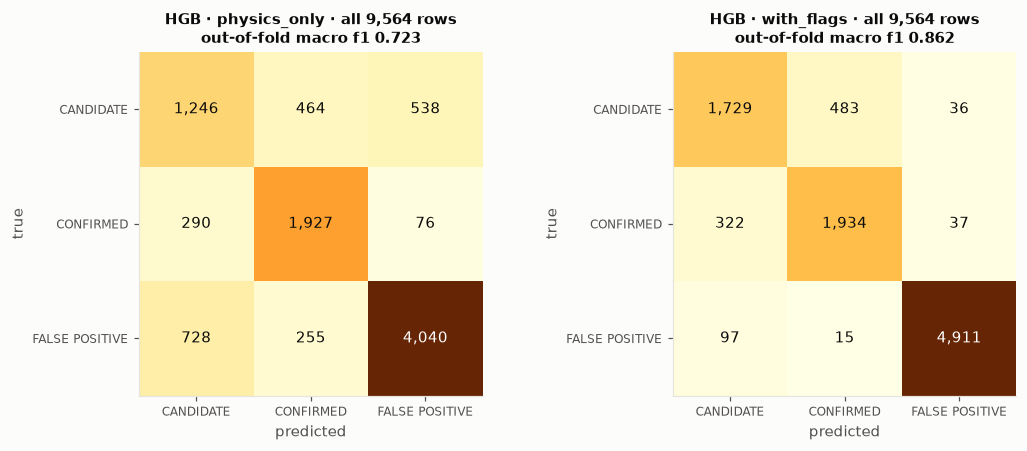

In [5]:
per_class = pd.DataFrame({name: r.folds[[f"f1_{c}" for c in CLASSES] + ["balanced_accuracy", "log_loss"]].mean() for name, r in results.items()}).round(3)
display(per_class)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, name in zip(axes, tables):
    X, y = tables[name]
    s = score(y, results[name].oof_pred)
    cm = s.confusion
    im = ax.imshow(cm, cmap=viz.SEQUENTIAL_CMAP, vmin=0, vmax=cm.max())
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=10, color="white" if cm[i, j] > 0.6 * cm.max() else viz.TEXT_PRIMARY)
    ax.set_xticks(range(3)); ax.set_yticks(range(3)); ax.set_xticklabels(CLASSES, fontsize=8); ax.set_yticklabels(CLASSES, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.grid(False)
    ax.set_title(f"HGB · {name} · all 9,564 rows\nout-of-fold macro f1 {s.f1_macro:.3f}", fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "confusion_hgb_oof.png"); plt.show()

## 4. Can the probabilities be trusted?

A model that says "80% planet" should be right about 80% of the time. The reliability diagram plots that per class for the physics-only model, using out-of-fold probabilities: raw boosting output versus the same model wrapped in isotonic calibration (fitted on inner folds). Brier score and log loss summarise the same thing (lower is better).

Note the trade-off in the table: calibration makes the probabilities truer but, because the raw model was trained with balanced class weights, the calibrated argmax leans toward the majority class and macro f1 drops. Probabilities and label decisions are two different jobs.

,raw,isotonic
log_loss,0.578,0.575
brier,0.342,0.335
f1_macro,0.723,0.701


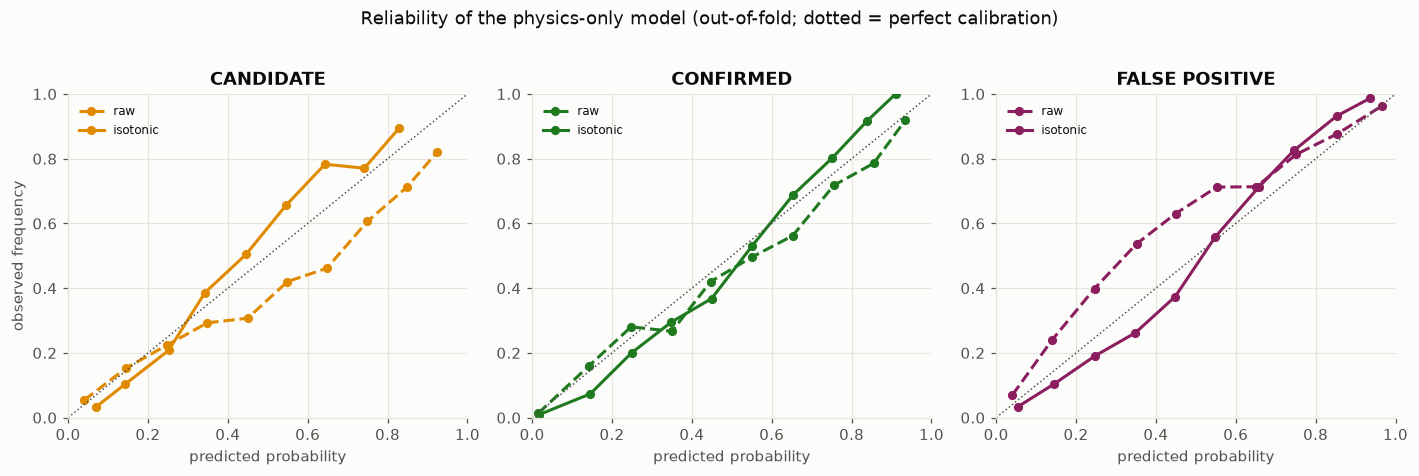

In [6]:
X, y = tables["physics_only"]
best = dict(Counter(tuple(sorted(p.items())) for p in results["physics_only"].params).most_common(1)[0][0])
folds = StratifiedKFold(5, shuffle=True, random_state=0)
proba_raw = results["physics_only"].oof_proba
calibrated = CalibratedClassifierCV(hgb_model(**best), method="isotonic", cv=3)
proba_cal = cross_val_predict(calibrated, X, y, cv=folds, method="predict_proba")
labels = [0, 1, 2]
metrics = pd.DataFrame({
    "raw":        {"log_loss": log_loss(y, proba_raw, labels=labels), "brier": brier_multiclass(y, proba_raw), "f1_macro": score(y, proba_raw.argmax(1)).f1_macro},
    "isotonic":   {"log_loss": log_loss(y, proba_cal, labels=labels), "brier": brier_multiclass(y, proba_cal), "f1_macro": score(y, proba_cal.argmax(1)).f1_macro},
}).round(4)
display(metrics)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, cls in zip(axes, CLASSES):
    for proba, ls, lab in ((proba_raw, "--", "raw"), (proba_cal, "-", "isotonic")):
        t = reliability_table(y, proba); t = t[t["class"] == cls]
        ax.plot(t["predicted"], t["observed"], marker="o", ls=ls, color=viz.CLASS_COLORS[cls], label=lab)
    ax.plot([0, 1], [0, 1], color=viz.TEXT_SECONDARY, lw=1, ls=":")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_title(cls); ax.set_xlabel("predicted probability")
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("observed frequency")
fig.suptitle("Reliability of the physics-only model (out-of-fold; dotted = perfect calibration)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "reliability_physics_only.png"); plt.show()

## 5. What the physics-only model actually uses

Permutation importance on a held-out split (the 2020 split, for continuity): how much macro f1 drops when one column is shuffled. No flags, no score, no names, so nothing here is leakage.

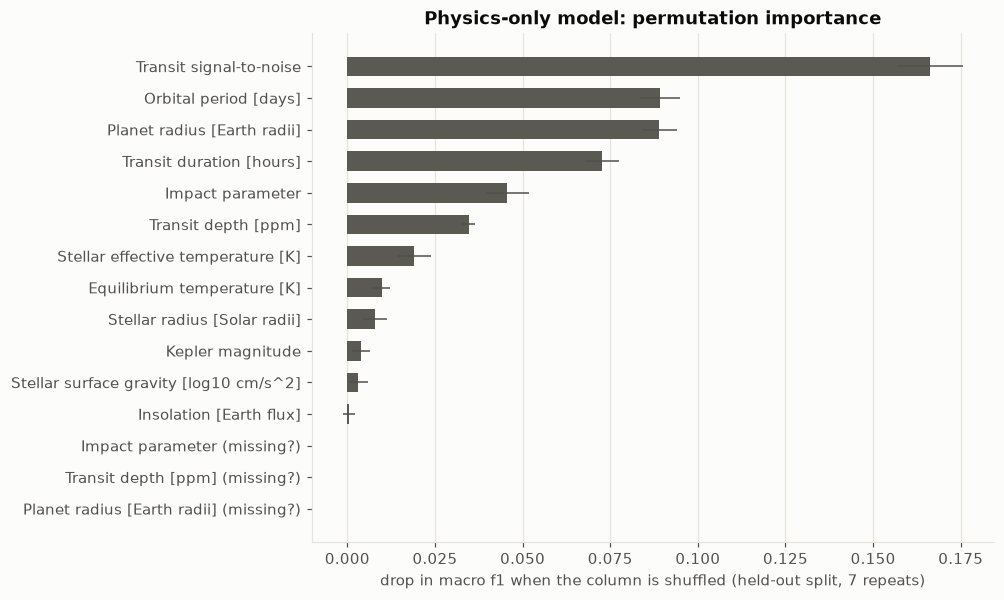

,column,drop_in_macro_f1,std
7,koi_model_snr,0.166,0.009
0,koi_period,0.089,0.006
4,koi_prad,0.089,0.005
2,koi_duration,0.073,0.005
1,koi_impact,0.046,0.006
3,koi_depth,0.035,0.002
8,koi_steff,0.019,0.005
5,koi_teq,0.010,0.002
10,koi_srad,0.008,0.003
11,koi_kepmag,0.004,0.003


In [7]:
X_train, X_test, y_train, y_test = split(X, y)
model = hgb_model(**best).fit(X_train, y_train)
imp = permutation_importance(model, X_test, y_test, scoring="f1_macro", n_repeats=7, random_state=0, n_jobs=-1)
importance = pd.DataFrame({"column": X.columns, "drop_in_macro_f1": imp.importances_mean, "std": imp.importances_std}).sort_values("drop_in_macro_f1", ascending=False)
fig, ax = viz.new_figure(8, 6)
top = importance.head(15).iloc[::-1]
ax.barh([label(c.replace("_missing", "")) + (" (missing?)" if c.endswith("_missing") else "") for c in top["column"]],
        top["drop_in_macro_f1"], xerr=top["std"], color=viz.NEUTRAL, height=0.62, error_kw={"elinewidth": 1, "ecolor": viz.TEXT_SECONDARY})
ax.set_xlabel("drop in macro f1 when the column is shuffled (held-out split, 7 repeats)")
ax.set_title("Physics-only model: permutation importance")
ax.grid(axis="y", visible=False)
fig.savefig(FIG_DIR / "permutation_importance_physics_only.png"); plt.show()
importance.head(10).round(4)

## 6. Save the physics-only model and the metrics

The saved model is the tuned physics-only classifier retrained on **all 9,564 rows**, with isotonic calibration, plus a column contract (the exact input columns, in order) so the app cannot feed it the wrong thing. It lives in `models/` (ignored by git) — Phase 5 decides whether it ships inside the app or is rebuilt by it.

In [8]:
import json
final = CalibratedClassifierCV(hgb_model(**best), method="isotonic", cv=5).fit(X, y)
contract = {"feature_set": "physics_only", "columns": list(X.columns), "classes": list(CLASSES), "class_codes": {c: i for i, c in enumerate(CLASSES)},
            "params": best, "trained_on": "cumulative_kaggle_snapshot.csv (9,564 rows)", "run_date": "2026-08-24",
            "oof_macro_f1_nested_cv": round(float(results["physics_only"].folds["f1_macro"].mean()), 4)}
dump(final, MODELS / "hgb_physics_only_calibrated.joblib")
(MODELS / "hgb_physics_only_calibrated.contract.json").write_text(json.dumps(contract, indent=2))
print("saved models/hgb_physics_only_calibrated.joblib and its contract:", json.dumps(contract, indent=1)[:600])

out = []
for name, r in results.items():
    f = r.folds.copy(); f.insert(0, "feature_set", name); f.insert(0, "model", "hgb_nested_cv"); out.append(f.reset_index())
out = pd.concat(out, ignore_index=True); out.insert(0, "run_date", "2026-08-24")
out.to_csv(TABLE_DIR / "07_models_v2_metrics.csv", index=False)
print("wrote reports/tables/07_models_v2_metrics.csv", out.shape)

saved models/hgb_physics_only_calibrated.joblib and its contract: {
 "feature_set": "physics_only",
 "columns": [
  "koi_period",
  "koi_impact",
  "koi_duration",
  "koi_depth",
  "koi_prad",
  "koi_teq",
  "koi_insol",
  "koi_model_snr",
  "koi_steff",
  "koi_slogg",
  "koi_srad",
  "koi_kepmag",
  "koi_impact_missing",
  "koi_depth_missing",
  "koi_prad_missing",
  "koi_teq_missing",
  "koi_insol_missing",
  "koi_model_snr_missing",
  "koi_steff_missing",
  "koi_slogg_missing",
  "koi_srad_missing",
  "koi_kepmag_missing"
 ],
 "classes": [
  "CANDIDATE",
  "CONFIRMED",
  "FALSE POSITIVE"
 ],
 "class_codes": {
  "CANDIDATE": 0,
  "CONFIRMED": 1,
  "FALSE P
wrote reports/tables/07_models_v2_metrics.csv (10, 11)


## Summary

- **Physics-only ceiling ≈ 0.72 macro f1** (nested CV), essentially unchanged from the dropna baseline: more rows and honest tuning do not conjure information the table does not contain. CANDIDATE is the weak class (f1 ≈ 0.55); FALSE POSITIVE ≈ 0.84 without any flag.
- **With the flags the model reaches ≈ 0.86**, the same as 2020's number once correctly labelled; the flags remain the difference.
- **Probabilities:** the raw model (trained with balanced class weights) under-states FALSE POSITIVE probabilities and over-states CANDIDATE ones; isotonic calibration straightens the reliability curves and improves log loss / Brier score modestly (0.578 → 0.575, 0.342 → 0.335). The trade-off: taking the argmax of *calibrated* probabilities favours the majority class and lowers macro f1 (0.723 → 0.701). The app should **show calibrated probabilities** and make the label decision with an explicit rule, not by argmax alone.
- **What drives the physics-only model:** see the permutation figure — transit depth, signal-to-noise, planet radius and the stellar parameters do the work.
- **Next:** the live archive table (`fetch_koi.py`, Phase 3) to see how the 2017-era labels have moved, then the app.